# 2D U-Net Training on C. elegans Nuclei

Train a 2D U-Net for nuclear instance segmentation using the C. elegans dataset
([Zenodo 5942575](https://zenodo.org/records/5942575)). The model learns **3-class semantic
segmentation** (background / boundary / interior), then a watershed post-processing step
recovers individual instances.

This notebook runs in **fast dev mode** on CPU (~10-15 min). For full training, switch to GPU
and increase `MAX_SLICES` and `N_EPOCHS`.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import time

import torch
torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import tifffile
from skimage.segmentation import find_boundaries, watershed
from skimage.measure import label, regionprops
from scipy import ndimage

print(f"PyTorch: {torch.__version__}")
print(f"Device: cpu")
DEVICE = torch.device("cpu")

PyTorch: 2.2.2
Device: cpu


In [2]:
# === Configuration ===
CONFIG = {
    # Data
    "data_dir": Path("../data/c_elegans/c_elegans_nuclei"),
    "slice_stride": 2,        # take every Nth z-slice (reduces correlation)
    "min_nuclei": 3,          # skip slices with fewer nuclei
    "pad_size": 144,          # pad 140x140 -> 144x144 (divisible by 2^3)
    
    # Fast dev mode — set MAX_SLICES=None for full training
    "max_slices": 500,        # limit training slices (None = use all)
    
    # Training
    "batch_size": 16,
    "n_epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    
    # Loss
    "class_weights": [1.0, 10.0, 8.0],  # bg, boundary, interior
    "dice_weight": 0.5,
    "ce_weight": 0.5,
    
    # Model
    "features": [32, 64, 128, 256],  # encoder channel sizes
    
    # Output
    "checkpoint_dir": Path("../data/checkpoints"),
    "seed": 42,
}

CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print("Config:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Config:
  data_dir: ../data/c_elegans/c_elegans_nuclei
  slice_stride: 2
  min_nuclei: 3
  pad_size: 144
  max_slices: 500
  batch_size: 16
  n_epochs: 20
  lr: 0.001
  weight_decay: 0.0001
  class_weights: [1.0, 10.0, 8.0]
  dice_weight: 0.5
  ce_weight: 0.5
  features: [32, 64, 128, 256]
  checkpoint_dir: ../data/checkpoints
  seed: 42


## 1. Data loading

In [3]:
def load_volumes(data_dir, split):
    """Load all TIF volumes for a given split."""
    img_dir = data_dir / split / "images"
    mask_dir = data_dir / split / "masks"
    volumes = []
    for img_path in sorted(img_dir.glob("*.tif")):
        img = tifffile.imread(str(img_path))    # (Y, X, Z) uint8
        mask = tifffile.imread(str(mask_dir / img_path.name))  # (Y, X, Z) uint32
        volumes.append((img, mask, img_path.stem))
    return volumes

train_volumes = load_volumes(CONFIG["data_dir"], "train")
val_volumes = load_volumes(CONFIG["data_dir"], "val")
test_volumes = load_volumes(CONFIG["data_dir"], "test")

print(f"Train: {len(train_volumes)} volumes")
print(f"Val:   {len(val_volumes)} volumes")
print(f"Test:  {len(test_volumes)} volumes")
print(f"\nExample volume shape: {train_volumes[0][0].shape}")

Train: 18 volumes
Val:   3 volumes
Test:  7 volumes

Example volume shape: (140, 140, 1244)


## 2. Target generation — 3-class semantic masks

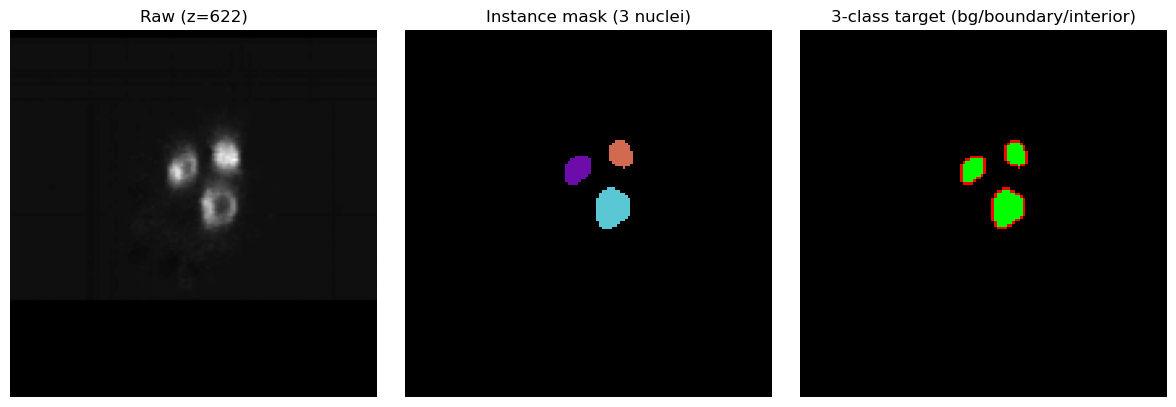

In [4]:
def instance_to_semantic(mask_slice):
    """Convert instance mask to 3-class: 0=bg, 1=boundary, 2=interior."""
    target = np.zeros_like(mask_slice, dtype=np.uint8)
    target[mask_slice > 0] = 2  # interior
    if mask_slice.max() > 0:
        bnd = find_boundaries(mask_slice, mode="inner")
        target[bnd] = 1  # boundary
    return target

# Visualize example
ex_img, ex_mask, ex_name = train_volumes[0]
mid_z = ex_img.shape[2] // 2

img_slice = ex_img[:, :, mid_z]
mask_slice = ex_mask[:, :, mid_z]
target_slice = instance_to_semantic(mask_slice)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title(f"Raw (z={mid_z})")
cmap_inst = ListedColormap(np.random.default_rng(42).random((max(mask_slice.max() + 1, 2), 3)))
cmap_inst.colors[0] = [0, 0, 0]
axes[1].imshow(mask_slice, cmap=cmap_inst, interpolation="nearest")
axes[1].set_title(f"Instance mask ({len(np.unique(mask_slice)) - 1} nuclei)")
cmap_3c = ListedColormap([[0, 0, 0], [1, 0, 0], [0, 1, 0]])
axes[2].imshow(target_slice, cmap=cmap_3c, interpolation="nearest", vmin=0, vmax=2)
axes[2].set_title("3-class target (bg/boundary/interior)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset and DataLoader

In [5]:
def normalize_slice(img_slice):
    """Percentile normalization to [0, 1]."""
    p1, p99 = np.percentile(img_slice, [1, 99])
    if p99 - p1 < 1e-8:
        return np.zeros_like(img_slice, dtype=np.float32)
    return np.clip((img_slice.astype(np.float32) - p1) / (p99 - p1), 0, 1)


def pad_to(arr, size):
    """Reflect-pad a 2D array to (size, size)."""
    h, w = arr.shape[:2]
    pad_h = size - h
    pad_w = size - w
    top = pad_h // 2
    left = pad_w // 2
    return np.pad(arr, ((top, pad_h - top), (left, pad_w - left)), mode="reflect")


def augment(img, target, rng):
    """Random augmentation applied identically to image and target."""
    # Random horizontal flip
    if rng.random() > 0.5:
        img = np.flip(img, axis=1).copy()
        target = np.flip(target, axis=1).copy()
    # Random vertical flip
    if rng.random() > 0.5:
        img = np.flip(img, axis=0).copy()
        target = np.flip(target, axis=0).copy()
    # Random 90-degree rotation
    if rng.random() > 0.5:
        k = rng.integers(1, 4)
        img = np.rot90(img, k).copy()
        target = np.rot90(target, k).copy()
    # Intensity jitter (image only)
    if rng.random() > 0.5:
        img = img * rng.uniform(0.8, 1.2) + rng.uniform(-0.1, 0.1)
        img = np.clip(img, 0, 1)
    # Gaussian noise (image only)
    if rng.random() > 0.7:
        img = img + rng.normal(0, 0.02, img.shape).astype(np.float32)
        img = np.clip(img, 0, 1)
    return img, target


class NucleiSliceDataset(Dataset):
    def __init__(self, volumes, stride=2, min_nuclei=3, pad_size=144,
                 max_slices=None, do_augment=False):
        self.pad_size = pad_size
        self.do_augment = do_augment
        self.rng = np.random.default_rng(42)
        
        # Pre-compute valid (volume_idx, z_idx) pairs
        self.slices = []
        for vol_idx, (img, mask, name) in enumerate(volumes):
            nz = img.shape[2]
            for z in range(0, nz, stride):
                mask_slice = mask[:, :, z]
                n_nuclei = len(np.unique(mask_slice)) - 1
                if n_nuclei >= min_nuclei:
                    self.slices.append((vol_idx, z))
        
        # Sub-sample if in fast dev mode
        if max_slices is not None and len(self.slices) > max_slices:
            idx = np.random.default_rng(42).choice(len(self.slices), max_slices, replace=False)
            self.slices = [self.slices[i] for i in sorted(idx)]
        
        self.volumes = volumes
    
    def __len__(self):
        return len(self.slices)
    
    def __getitem__(self, idx):
        vol_idx, z = self.slices[idx]
        img, mask, _ = self.volumes[vol_idx]
        
        img_slice = normalize_slice(img[:, :, z])
        target = instance_to_semantic(mask[:, :, z])
        
        # Pad to target size
        img_slice = pad_to(img_slice, self.pad_size)
        target = pad_to(target, self.pad_size)
        
        # Augment
        if self.do_augment:
            img_slice, target = augment(img_slice, target, self.rng)
        
        # To tensors
        img_tensor = torch.from_numpy(img_slice.astype(np.float32)).unsqueeze(0)  # (1, H, W)
        target_tensor = torch.from_numpy(target.astype(np.int64))  # (H, W)
        
        return img_tensor, target_tensor


# Create datasets
train_ds = NucleiSliceDataset(
    train_volumes, stride=CONFIG["slice_stride"], min_nuclei=CONFIG["min_nuclei"],
    pad_size=CONFIG["pad_size"], max_slices=CONFIG["max_slices"], do_augment=True,
)
val_ds = NucleiSliceDataset(
    val_volumes, stride=CONFIG["slice_stride"], min_nuclei=CONFIG["min_nuclei"],
    pad_size=CONFIG["pad_size"], max_slices=None, do_augment=False,
)

print(f"Train slices: {len(train_ds)}")
print(f"Val slices:   {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

# Sanity check
x, y = train_ds[0]
print(f"\nSample: image {x.shape} {x.dtype}, target {y.shape} {y.dtype}")
print(f"Target classes: {torch.unique(y).tolist()}")

Train slices: 500
Val slices:   1340

Sample: image torch.Size([1, 144, 144]) torch.float32, target torch.Size([144, 144]) torch.int64
Target classes: [0, 1, 2]


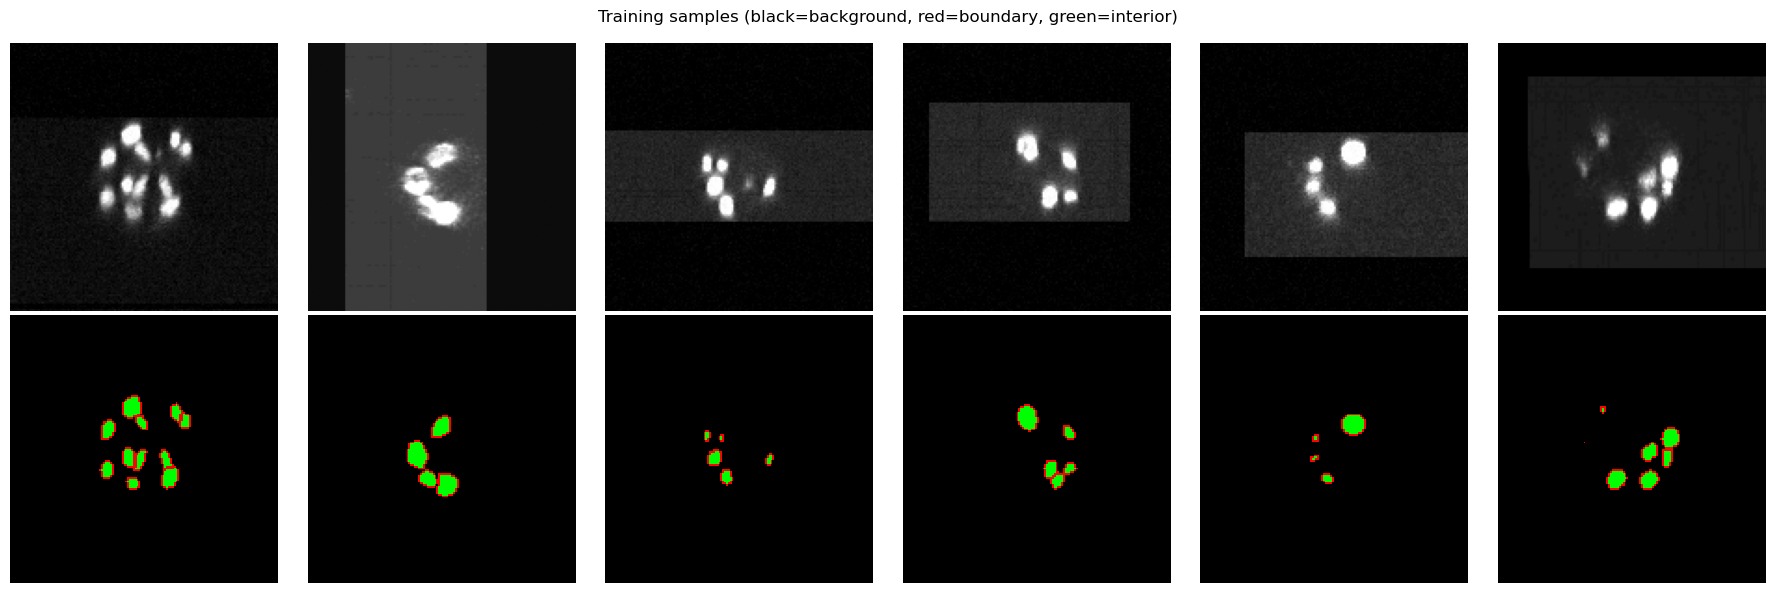

In [16]:
# Visualize a few training samples
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
cmap_3c = ListedColormap([[0, 0, 0], [1, 0, 0], [0, 1, 0]])

for i in range(6):
    x, y = train_ds[i * len(train_ds) // 6]
    axes[0, i].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(y, cmap=cmap_3c, interpolation="nearest", vmin=0, vmax=2)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=10)
axes[1, 0].set_ylabel("Target", fontsize=10)
plt.suptitle("Training samples (black=background, red=boundary, green=interior)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. U-Net model

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, features=None):
        super().__init__()
        if features is None:
            features = [32, 64, 128, 256]
        
        # Encoder
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_channels
        for f in features[:-1]:
            self.encoders.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f
        
        # Bottleneck
        self.bottleneck = DoubleConv(features[-2], features[-1])
        
        # Decoder
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        for f in reversed(features[:-1]):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
        
        # Output
        self.final = nn.Conv2d(features[0], out_channels, 1)
    
    def forward(self, x):
        # Encoder path
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)
        
        x = self.bottleneck(x)
        
        # Decoder path
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        
        return self.final(x)


model = UNet(in_channels=1, out_channels=3, features=CONFIG["features"]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {n_params:,}")

# Verify forward pass
with torch.no_grad():
    dummy = torch.randn(1, 1, 144, 144).to(DEVICE)
    out = model(dummy)
    print(f"Input:  {dummy.shape}")
    print(f"Output: {out.shape}")

U-Net parameters: 1,926,499
Input:  torch.Size([1, 1, 144, 144])
Output: torch.Size([1, 3, 144, 144])


## 5. Loss function

In [8]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        targets_one_hot = F.one_hot(targets, self.num_classes)  # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)
        
        dice = 0.0
        for c in range(self.num_classes):
            p = probs[:, c].contiguous().view(-1)
            g = targets_one_hot[:, c].contiguous().view(-1)
            intersection = (p * g).sum()
            dice += (2.0 * intersection + self.smooth) / (p.sum() + g.sum() + self.smooth)
        
        return 1.0 - dice / self.num_classes


class CombinedLoss(nn.Module):
    def __init__(self, class_weights, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32))
        self.dice = DiceLoss(num_classes=len(class_weights))
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
    
    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice(logits, targets)


criterion = CombinedLoss(
    class_weights=CONFIG["class_weights"],
    ce_weight=CONFIG["ce_weight"],
    dice_weight=CONFIG["dice_weight"],
).to(DEVICE)

print("Loss: weighted CE + Dice")
print(f"Class weights: {CONFIG['class_weights']}")

Loss: weighted CE + Dice
Class weights: [1.0, 10.0, 8.0]


## 6. Training

In [9]:
def compute_dice_per_class(logits, targets, num_classes=3):
    """Compute Dice score for each class."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    dice_scores = []
    for c in range(num_classes):
        p = (preds == c).float().view(-1)
        g = (targets == c).float().view(-1)
        intersection = (p * g).sum()
        dice = (2.0 * intersection + 1.0) / (p.sum() + g.sum() + 1.0)
        dice_scores.append(dice.item())
    return dice_scores


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    dice_sums = [0.0, 0.0, 0.0]
    n_batches = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        dice = compute_dice_per_class(logits.detach(), y)
        for c in range(3):
            dice_sums[c] += dice[c]
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_dice = [d / n_batches for d in dice_sums]
    return avg_loss, avg_dice


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    dice_sums = [0.0, 0.0, 0.0]
    n_batches = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item()
        dice = compute_dice_per_class(logits, y)
        for c in range(3):
            dice_sums[c] += dice[c]
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_dice = [d / n_batches for d in dice_sums]
    return avg_loss, avg_dice

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)

# Training history
history = {"train_loss": [], "val_loss": [],
           "train_dice": [], "val_dice": [], "lr": []}

best_val_dice = 0.0
best_epoch = 0
checkpoint_path = CONFIG["checkpoint_dir"] / "unet_best.pt"

print(f"Training for {CONFIG['n_epochs']} epochs...")
print(f"{'Epoch':>5s}  {'Train Loss':>10s}  {'Val Loss':>10s}  "
      f"{'BG Dice':>8s}  {'Bnd Dice':>8s}  {'Int Dice':>8s}  {'Mean FG':>8s}  {'Time':>6s}")
print("-" * 80)

for epoch in range(CONFIG["n_epochs"]):
    t0 = time.time()
    
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)
    
    # Mean foreground Dice (boundary + interior)
    mean_fg_dice = (val_dice[1] + val_dice[2]) / 2
    
    scheduler.step(val_loss)
    
    # Save best model
    if mean_fg_dice > best_val_dice:
        best_val_dice = mean_fg_dice
        best_epoch = epoch
        torch.save(model.state_dict(), checkpoint_path)
    
    # Log
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    
    elapsed = time.time() - t0
    marker = " *" if epoch == best_epoch and epoch > 0 else ""
    print(f"{epoch+1:>5d}  {train_loss:>10.4f}  {val_loss:>10.4f}  "
          f"{val_dice[0]:>8.4f}  {val_dice[1]:>8.4f}  {val_dice[2]:>8.4f}  "
          f"{mean_fg_dice:>8.4f}  {elapsed:>5.1f}s{marker}")

print(f"\nBest val FG Dice: {best_val_dice:.4f} at epoch {best_epoch + 1}")
print(f"Checkpoint saved to: {checkpoint_path}")

/opt/anaconda3/envs/zebrafish-unet/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Training for 20 epochs...
Epoch  Train Loss    Val Loss   BG Dice  Bnd Dice  Int Dice   Mean FG    Time
--------------------------------------------------------------------------------
    1      0.6912      0.6098    0.9932    0.3241    0.6056    0.4649  229.6s
    2      0.5185      0.4662    0.9916    0.2799    0.7209    0.5004  231.0s *
    3      0.4265      0.3938    0.9916    0.2991    0.7445    0.5218  228.9s *
    4      0.3592      0.3383    0.9912    0.3446    0.7719    0.5583  231.8s *
    5      0.3138      0.3195    0.9901    0.3378    0.7358    0.5368  233.5s
    6      0.2799      0.2925    0.9895    0.3015    0.7501    0.5258  234.8s
    7      0.2604      0.2582    0.9937    0.4110    0.7917    0.6014  234.8s *
    8      0.2499      0.2482    0.9925    0.3919    0.7901    0.5910  231.5s
    9      0.2396      0.2528    0.9929    0.4382    0.7419    0.5901  231.1s
   10      0.2359      0.2697    0.9959    0.4806    0.6947    0.5876  229.9s
   11      0.2351      0.24

## 7. Training curves

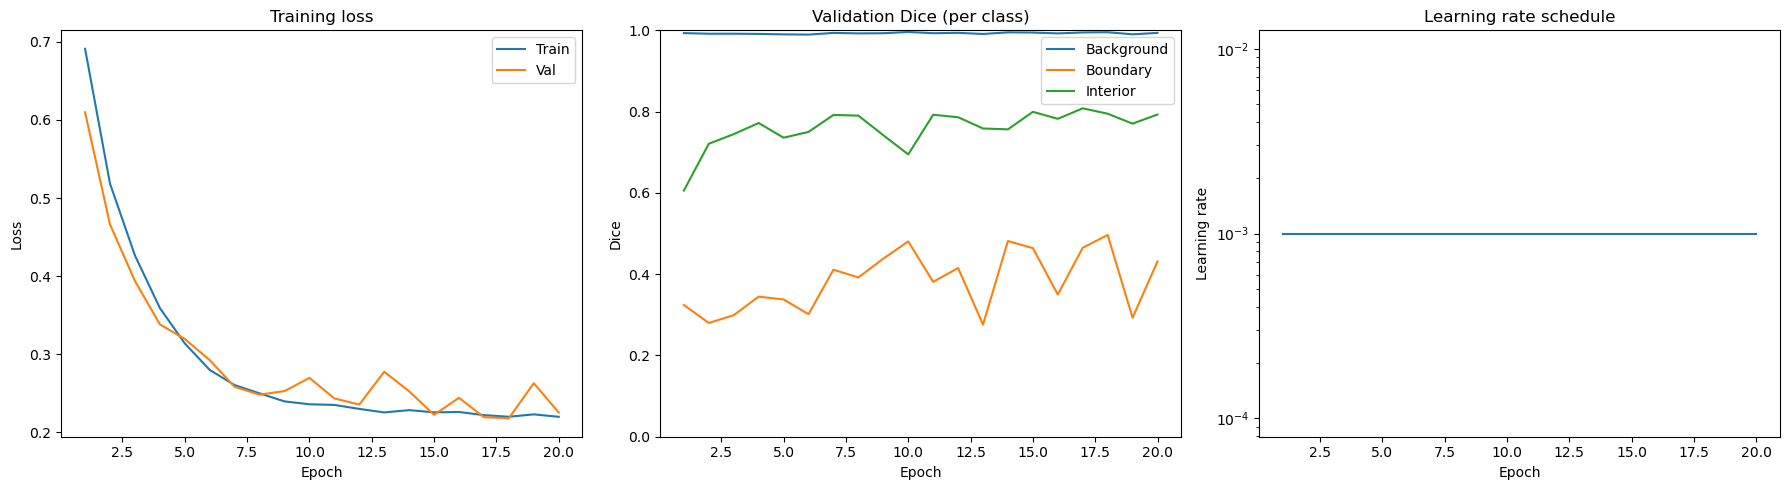

In [11]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].legend()

# Per-class Dice
class_names = ["Background", "Boundary", "Interior"]
for c, name in enumerate(class_names):
    vals = [d[c] for d in history["val_dice"]]
    axes[1].plot(epochs, vals, label=name)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_title("Validation Dice (per class)")
axes[1].legend()
axes[1].set_ylim(0, 1)

# LR
axes[2].plot(epochs, history["lr"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_title("Learning rate schedule")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

## 8. Evaluation — qualitative results

In [12]:
# Load best model
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Loaded best model from epoch {best_epoch + 1}")

# Final validation metrics
val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)
print(f"\nValidation metrics:")
print(f"  Loss:          {val_loss:.4f}")
print(f"  Dice BG:       {val_dice[0]:.4f}")
print(f"  Dice Boundary: {val_dice[1]:.4f}")
print(f"  Dice Interior: {val_dice[2]:.4f}")
print(f"  Mean FG Dice:  {(val_dice[1] + val_dice[2]) / 2:.4f}")

Loaded best model from epoch 18

Validation metrics:
  Loss:          0.2180
  Dice BG:       0.9954
  Dice Boundary: 0.4964
  Dice Interior: 0.7948
  Mean FG Dice:  0.6456


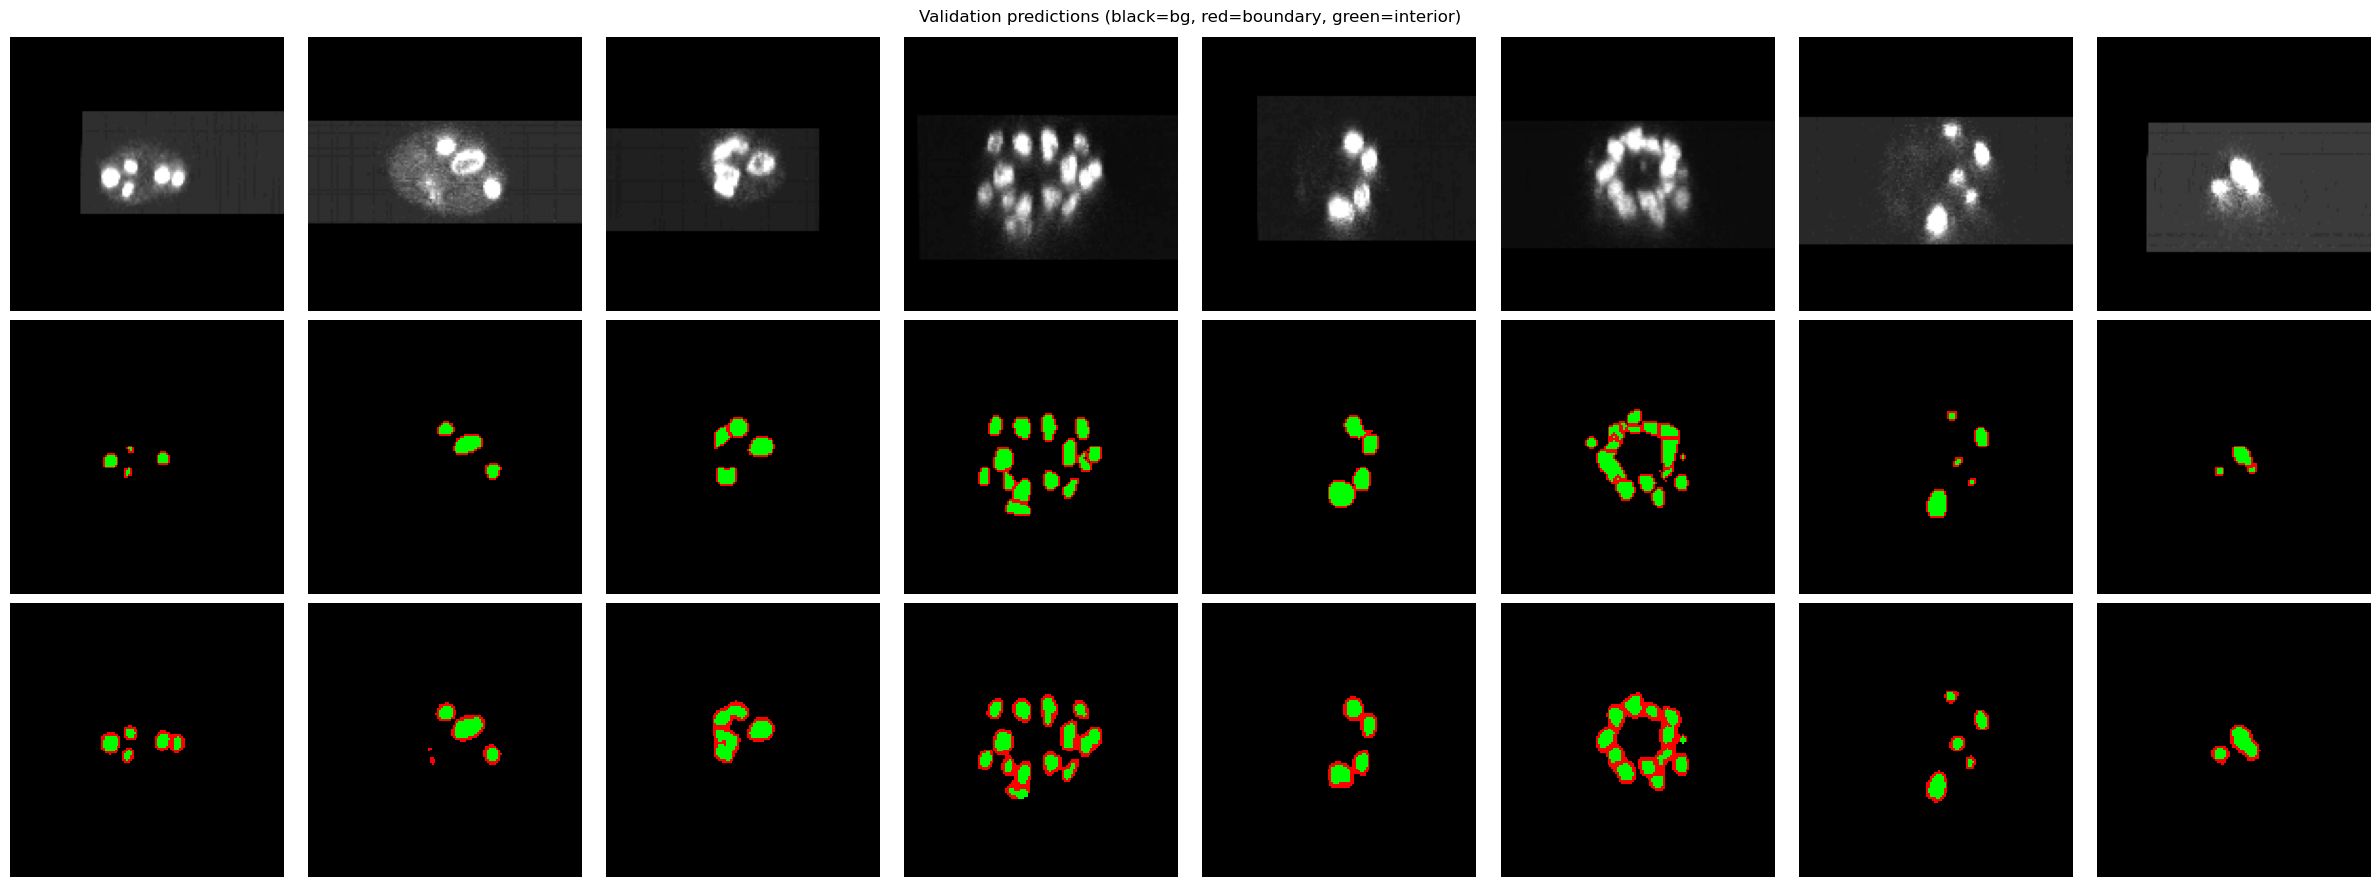

In [13]:
# Show predictions on validation samples
cmap_3c = ListedColormap([[0, 0, 0], [1, 0, 0], [0, 1, 0]])
n_show = 8
indices = np.linspace(0, len(val_ds) - 1, n_show, dtype=int)

fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))

for j, idx in enumerate(indices):
    x, y = val_ds[idx]
    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(dim=1)[0].cpu().numpy()
    
    axes[0, j].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off")
    axes[1, j].imshow(y, cmap=cmap_3c, interpolation="nearest", vmin=0, vmax=2)
    axes[1, j].axis("off")
    axes[2, j].imshow(pred, cmap=cmap_3c, interpolation="nearest", vmin=0, vmax=2)
    axes[2, j].axis("off")

axes[0, 0].set_ylabel("Raw", fontsize=10)
axes[1, 0].set_ylabel("Ground truth", fontsize=10)
axes[2, 0].set_ylabel("Prediction", fontsize=10)
plt.suptitle("Validation predictions (black=bg, red=boundary, green=interior)", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Instance segmentation — semantic to instances

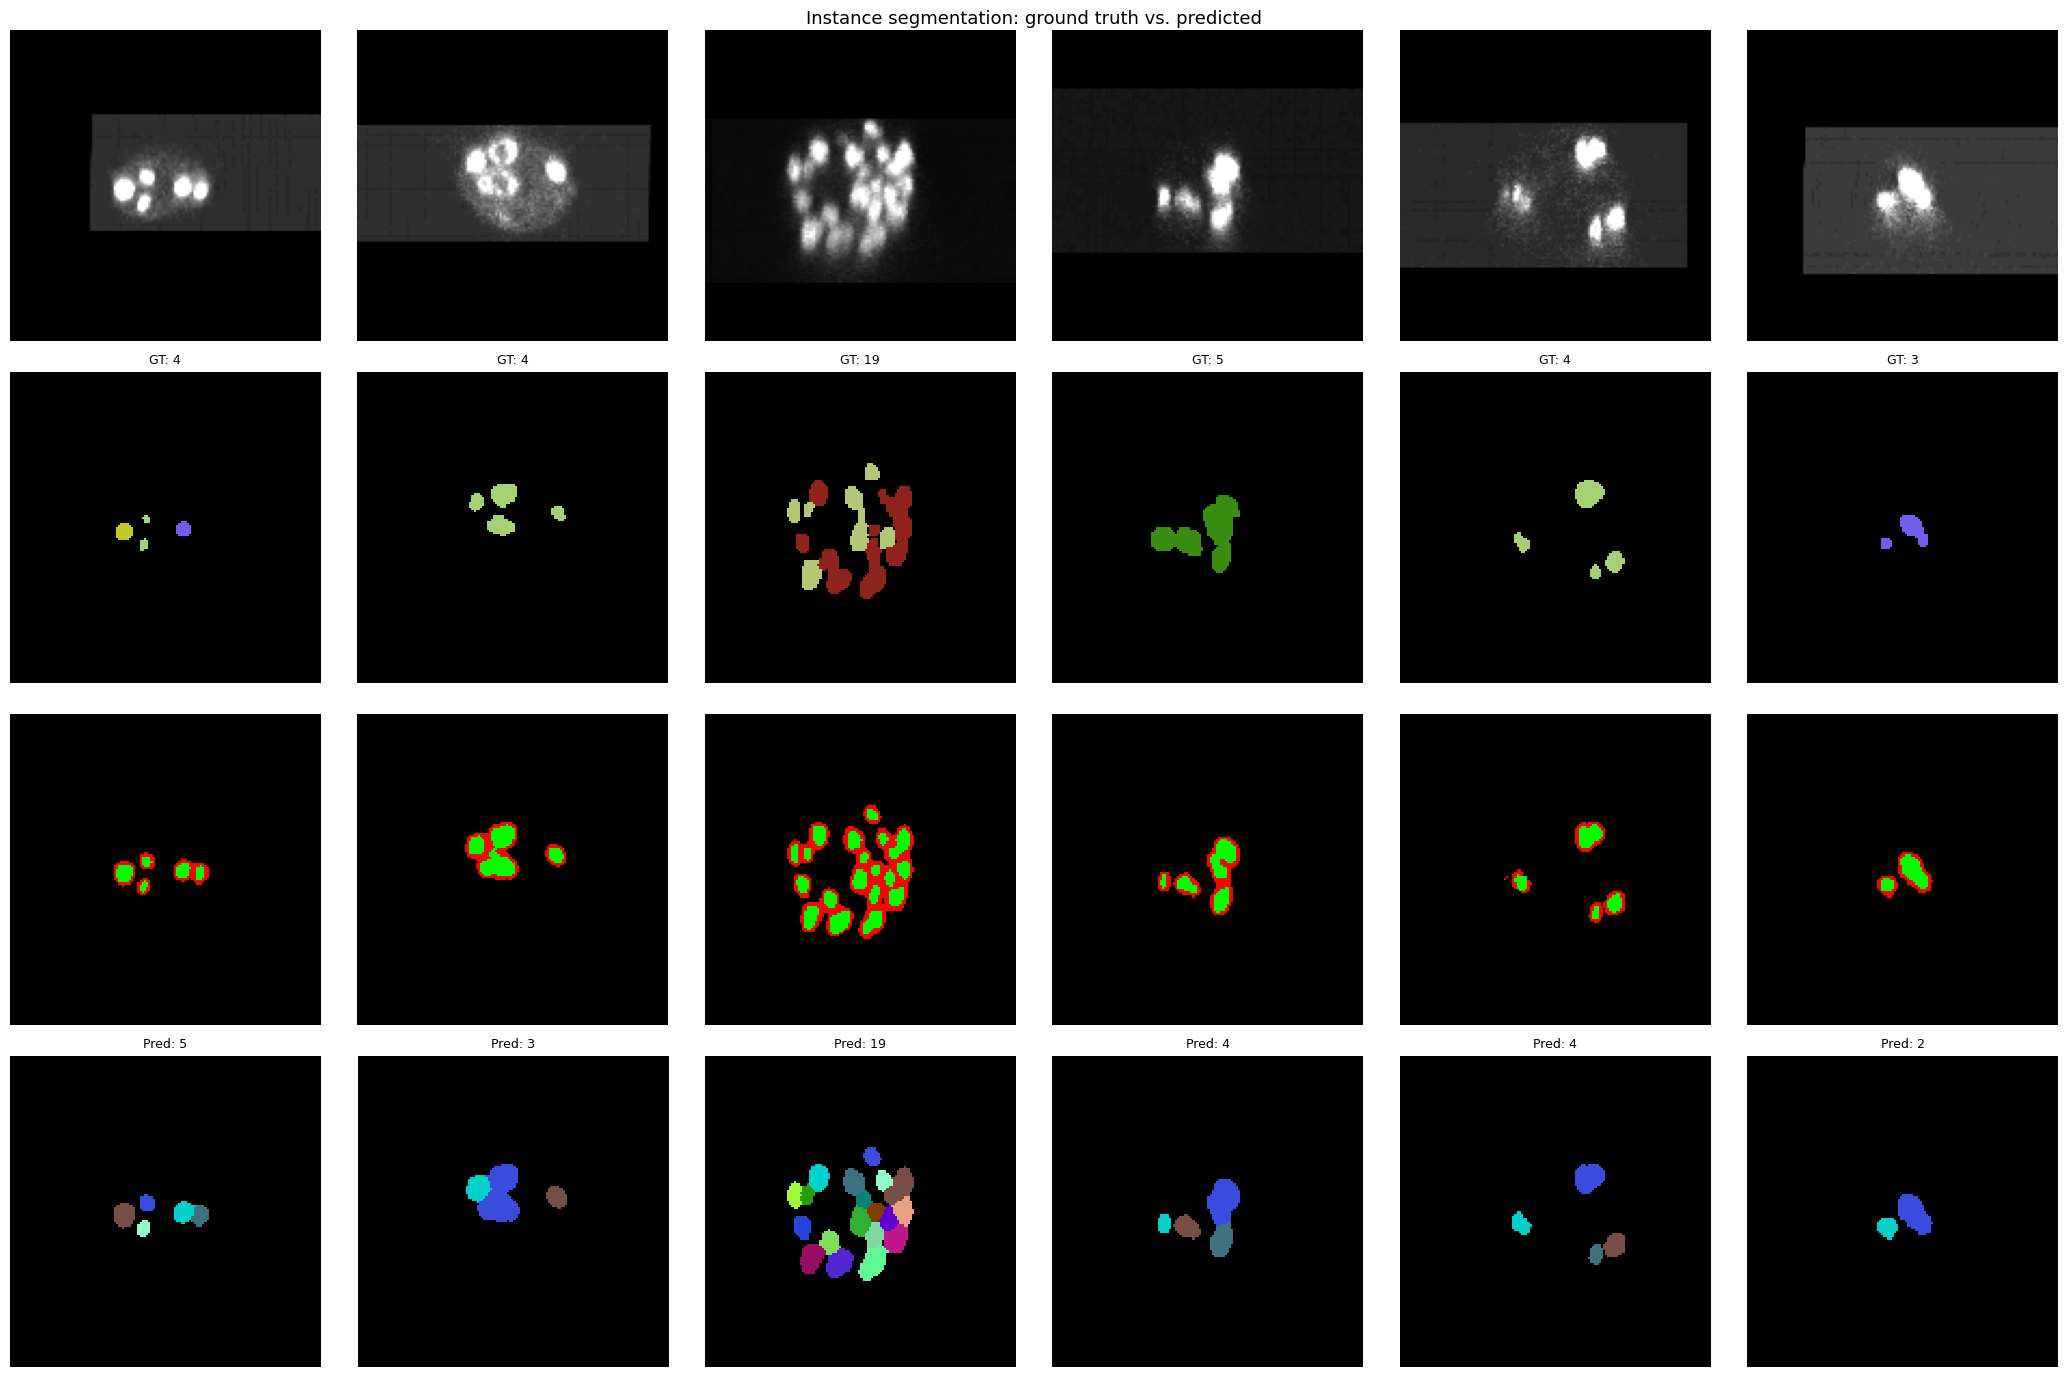

In [14]:
def semantic_to_instances(pred_3class):
    """Convert 3-class prediction to instance labels via watershed."""
    interior = (pred_3class == 2)
    foreground = (pred_3class >= 1)  # interior + boundary
    
    # Connected components on interior -> seeds
    seeds = label(interior)
    if seeds.max() == 0:
        return seeds
    
    # Expand seeds into boundary regions via watershed
    distance = ndimage.distance_transform_edt(interior)
    instances = watershed(-distance, seeds, mask=foreground)
    return instances


# Show instance segmentation results on validation data
n_show = 6
indices = np.linspace(0, len(val_ds) - 1, n_show, dtype=int)

fig, axes = plt.subplots(4, n_show, figsize=(3.5 * n_show, 14))

for j, idx in enumerate(indices):
    # Get prediction
    x, y = val_ds[idx]
    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(dim=1)[0].cpu().numpy()
    
    # Ground truth instances from the original mask
    vol_idx, z = val_ds.slices[idx]
    gt_instances = val_ds.volumes[vol_idx][1][:, :, z]
    gt_instances_padded = pad_to(gt_instances, CONFIG["pad_size"])
    
    # Predicted instances
    pred_instances = semantic_to_instances(pred)
    
    n_gt = len(np.unique(gt_instances_padded)) - 1
    n_pred = len(np.unique(pred_instances)) - 1
    
    # Plot
    axes[0, j].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off")
    
    cmap_gt = ListedColormap(np.random.default_rng(42).random((max(n_gt + 1, 2), 3)))
    cmap_gt.colors[0] = [0, 0, 0]
    axes[1, j].imshow(gt_instances_padded, cmap=cmap_gt, interpolation="nearest")
    axes[1, j].set_title(f"GT: {n_gt}", fontsize=9)
    axes[1, j].axis("off")
    
    axes[2, j].imshow(pred, cmap=cmap_3c, interpolation="nearest", vmin=0, vmax=2)
    axes[2, j].axis("off")
    
    cmap_pred = ListedColormap(np.random.default_rng(7).random((max(n_pred + 1, 2), 3)))
    cmap_pred.colors[0] = [0, 0, 0]
    axes[3, j].imshow(pred_instances, cmap=cmap_pred, interpolation="nearest")
    axes[3, j].set_title(f"Pred: {n_pred}", fontsize=9)
    axes[3, j].axis("off")

axes[0, 0].set_ylabel("Raw", fontsize=10)
axes[1, 0].set_ylabel("GT instances", fontsize=10)
axes[2, 0].set_ylabel("Semantic pred", fontsize=10)
axes[3, 0].set_ylabel("Pred instances", fontsize=10)
plt.suptitle("Instance segmentation: ground truth vs. predicted", fontsize=13)
plt.tight_layout()
plt.show()

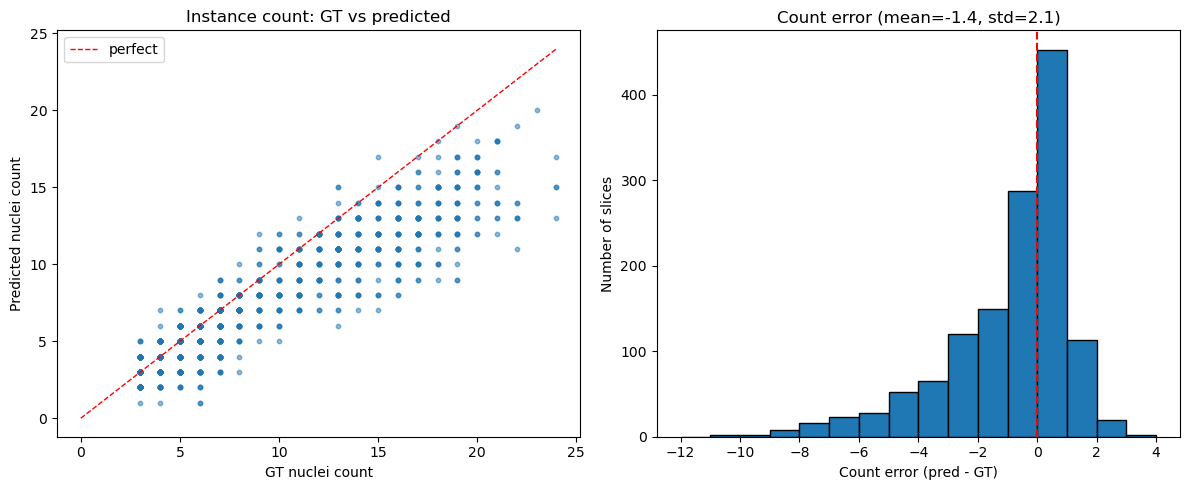

In [15]:
# Count comparison across all validation slices
gt_counts = []
pred_counts = []

for idx in range(len(val_ds)):
    x, y = val_ds[idx]
    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(dim=1)[0].cpu().numpy()
    
    vol_idx, z = val_ds.slices[idx]
    gt_inst = val_ds.volumes[vol_idx][1][:, :, z]
    pred_inst = semantic_to_instances(pred)
    
    gt_counts.append(len(np.unique(gt_inst)) - 1)
    pred_counts.append(len(np.unique(pred_inst)) - 1)

gt_counts = np.array(gt_counts)
pred_counts = np.array(pred_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(gt_counts, pred_counts, s=10, alpha=0.5)
max_val = max(gt_counts.max(), pred_counts.max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=1, label="perfect")
axes[0].set_xlabel("GT nuclei count")
axes[0].set_ylabel("Predicted nuclei count")
axes[0].set_title("Instance count: GT vs predicted")
axes[0].legend()

errors = pred_counts - gt_counts
axes[1].hist(errors, bins=range(errors.min() - 1, errors.max() + 2), edgecolor="black")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("Count error (pred - GT)")
axes[1].set_ylabel("Number of slices")
axes[1].set_title(f"Count error (mean={errors.mean():.1f}, std={errors.std():.1f})")

plt.tight_layout()
plt.show()

## Next steps

- **Full training on GPU**: set `max_slices=None`, `batch_size=64`, `n_epochs=100`, move to Linux GPU machine
- **3D U-Net**: extend to process volumetric patches for better z-context
- **Transfer to zebrafish**: fine-tune this model on watershed-labeled zebrafish patches
- **Instance metrics**: compute matching IoU (AP@0.5) for proper instance segmentation evaluation